# Session 7 — Data Validation & Quality Checks

### Modern Data Engineering · Week 4 · Module 1

**Instructor:** Ameer Ul Islam · Senior Data Engineer @ Optimizely
** Depthware **

---

> *"The danger isn't data that breaks your code. It's data that quietly lies to it."*

In this session you'll learn how to stop bad data **at the door** — before it flows
downstream into a dashboard, a model, or a decision someone makes with real money.

**By the end you'll be able to:**

- Explain **why** silent data corruption is the most expensive kind of bug
- Write **validation checks by hand** in plain Python / Pandas
- Understand **why** hand-rolled checks stop scaling
- Use **Great Expectations (1.x)** — the industry-standard validation framework
- Build a reusable **quality suite** and run it against a fresh batch of data
- Catch planted bugs in a deliberately broken *"Tuesday's load"*

---
## 1. A Tuesday that cost \$40,000

Picture a small e-commerce company. Every night, a pipeline loads the day's orders
from a payment provider into a warehouse. A dashboard reads from that warehouse.
Every morning, the finance team checks revenue over coffee.

For two years it works flawlessly. Then one Tuesday, the payment provider ships a
tiny update. A bug in *their* refund logic starts sending a handful of amounts as
**negative numbers**. And in a few rows, the `status` field arrives as the string
`"FREE"` instead of `paid` / `refunded` / `pending`.

Here's the thing: **nothing crashes.**

- The CSV still parses.
- Pandas still loads it.
- The warehouse still accepts it.
- The dashboard still renders.

The bad data just... flows through. Quietly. The negative amounts drag down the
revenue total. The `"FREE"` orders break a downstream `GROUP BY status` query that
someone wrote assuming only three statuses ever existed.

A week later, finance asks: *"Why did revenue drop 12% last Tuesday?"* It takes three
engineers two days to trace it back to that one upstream change.

The fix would have taken **one line of validation** running at ingestion:

> *every amount must be ≥ 0, and every status must be one of three known values.*

That line is what this session is about.

### The mental model: data validation is a contract

When you sign a contract, both sides agree on terms *before* doing business. Data
validation is the same idea applied to data:

> **You declare, in advance, what valid data looks like. Then you check every incoming
> batch against that declaration — and you reject (or quarantine) anything that violates it.**

Think of it like a **bouncer at a club door**. The bouncer doesn't inspect people once
they're inside dancing — that's too late. They check IDs *at the entrance*. Validation
is the bouncer for your data pipeline: it checks every row at the door, before it gets
in and causes trouble.

The rest of this session builds that bouncer — first by hand, then with a real framework.

---
## 2. Setup

We'll work with a synthetic **orders** dataset from a fictional Turkish e-commerce
company. There are two files in the `data/` folder:

| File | What it is |
|------|------------|
| `orders_monday.csv`  | A **clean** load — the data as it *should* look |
| `orders_tuesday.csv` | A **broken** load — the same pipeline, the day it went wrong |

We'll learn validation on Monday's clean data, then unleash our checks on Tuesday's
mess and watch them catch exactly what the story warned about.

Run the cell below to load both batches.

In [87]:
import pandas as pd
import numpy as np

# Load both batches
monday = pd.read_csv("data/orders_monday.csv")
tuesday = pd.read_csv("data/orders_tuesday.csv")

print(f"Monday  (clean):  {monday.shape[0]} rows, {monday.shape[1]} columns")
print(f"Tuesday (broken): {tuesday.shape[0]} rows, {tuesday.shape[1]} columns")

monday.head()

Monday  (clean):  1000 rows, 7 columns
Tuesday (broken): 1010 rows, 7 columns


,order_id,customer,city,amount,quantity,status,order_date
0,10000,Ayse Kaya,Antalya,59.03,2,paid,2026-03-02
1,10001,Merve Aslan,Bursa,372.03,5,paid,2026-03-02
2,10002,Hatice Ozturk,Izmir,111.93,1,pending,2026-03-02
3,10003,Mustafa Dogan,Antalya,130.34,3,refunded,2026-03-02
4,10004,Mustafa Dogan,Istanbul,509.50,5,paid,2026-03-02


In [88]:
tuesday.head()

,order_id,customer,city,amount,quantity,status,order_date
0,11000,Sumeyye Polat,Bursa,-24.89,5,paid,2026-03-03
1,11001,NaN,Bursa,369.47,1,paid,2026-03-03
2,11002,Bilal Erdogan,Ankara,498.28,4,paid,2026-03-03
3,11003,NaN,Ankara,373.71,3,paid,2026-03-03
4,11004,Zeynep Arslan,Antalya,113.21,4,paid,2026-03-03


Notice that **both files load without error.** Tuesday has a few more rows (some got
double-ingested), but Pandas is perfectly happy. This is the trap: *parsing successfully
is not the same as being correct.*

Let's look at the columns we care about:

- `order_id` — unique identifier, should never repeat
- `customer` — required, should never be missing
- `city` — one of a known set of cities
- `amount` — money, must be ≥ 0
- `quantity` — at least 1
- `status` — one of `paid` / `refunded` / `pending`
- `order_date` — an ISO date string (`YYYY-MM-DD`)

---
## 3. Validation by hand

Before reaching for any framework, let's build the bouncer ourselves. This matters:
a framework like Great Expectations is just **automating checks you could write by
hand**. If you understand the hand-rolled version, the framework becomes obvious instead
of magical.

A validation check, at its core, answers a yes/no question about a column:

> *"Is this true for every row?"*

Let's write a few, starting with the two from our \$40,000 story.

### Check 1 — Every `amount` must be ≥ 0

The question: *are there any negative amounts?* In Pandas, a comparison like
`df["amount"] < 0` gives us a boolean Series — `True` wherever the rule is **violated**.

In [89]:
def check_amount_non_negative(df):
    violations = df[df["amount"] < 0]
    passed = (len(violations) == 0)
    return passed, violations

# Run it on Monday (clean)
passed, bad = check_amount_non_negative(monday)
print(f"Monday  → passed: {passed}  ({len(bad)} violations)")

# Run it on Tuesday (broken)
passed, bad = check_amount_non_negative(tuesday)
print(f"Tuesday → passed: {passed}  ({len(bad)} violations)")
print()
print("The offending rows:")
bad[["order_id", "customer", "amount", "status"]].head(16)

Monday  → passed: True  (0 violations)
Tuesday → passed: False  (16 violations)

The offending rows:


,order_id,customer,amount,status
0,11000,Sumeyye Polat,-24.89,paid
102,11102,Hatice Ozturk,-789.41,refunded
123,11123,Elif Yildiz,-720.68,paid
165,11165,Mustafa Dogan,-332.73,paid
179,11179,Emre Celik,-700.96,paid
208,11208,Mustafa Dogan,-142.21,paid
226,11226,Yusuf Demir,-645.38,paid
264,11264,Elif Yildiz,-356.34,paid
452,11452,Ahmet Kurt,-197.95,paid
498,11498,Omar Aydin,-289.02,paid


There it is — Monday passes, Tuesday fails, and we can see *exactly which rows* are
wrong. This single check would have caught the revenue bug on the very first run.

### Check 2 — Every `status` must be in the allowed set

The question: *is every status one of our three known values?* We use `.isin()` to test
membership, then flip it with `~` (NOT) to find the rows that are **not** in the set.

In [90]:
ALLOWED_STATUSES = {"paid", "refunded", "pending"}

def check_status_allowed(df):
    violations = df[~df["status"].isin(ALLOWED_STATUSES)]
    passed = len(violations) == 0
    return passed, violations

passed, bad = check_status_allowed(tuesday)
print(f"Tuesday → passed: {passed}  ({len(bad)} violations)")
print()
print("Unexpected status values found:", bad["status"].unique())
bad[["order_id", "customer", "amount", "status"]].head(21)

Tuesday → passed: False  (21 violations)

Unexpected status values found: ['FREE']


,order_id,customer,amount,status
97,11097,Ayse Kaya,153.63,FREE
151,11151,Zeynep Arslan,644.09,FREE
220,11220,Zeynep Arslan,362.97,FREE
289,11289,Yusuf Demir,550.80,FREE
321,11321,Fatma Sahin,226.97,FREE
323,11323,Sumeyye Polat,566.19,FREE
329,11329,Fatma Sahin,728.09,FREE
368,11368,Ayse Kaya,359.60,FREE
376,11376,Hatice Ozturk,185.30,FREE
412,11412,Hatice Ozturk,316.04,FREE


The `"FREE"` value that would have broken the downstream `GROUP BY` — caught.

### Check 3 — `customer` must never be missing

The question: *are there null customers?* A missing required field is one of the most
common real-world data problems.

In [91]:
def check_customer_not_null(df):
    violations = df[df["customer"].isna()]
    passed = len(violations) == 0
    return passed, violations

passed, bad = check_customer_not_null(tuesday)
print(f"Tuesday → passed: {passed}  ({len(bad)} null customers)")
bad[["order_id", "customer", "amount", "status"]].head(30)

Tuesday → passed: False  (30 null customers)


,order_id,customer,amount,status
1,11001,NaN,369.47,paid
3,11003,NaN,373.71,paid
5,11005,NaN,324.00,paid
53,11053,NaN,543.84,paid
73,11073,NaN,297.71,paid
86,11086,NaN,409.55,paid
117,11117,NaN,443.96,paid
185,11185,NaN,284.82,refunded
243,11243,NaN,235.88,refunded
250,11250,NaN,165.37,refunded


### Check 4 — `order_id` must be unique

The question: *did any orders get ingested twice?* Duplicated primary keys silently
double-count revenue.

In [92]:
def check_order_id_unique(df):
    dup_mask = df["order_id"].duplicated(keep=False)  # keep=False flags ALL copies
    violations = df[dup_mask]
    passed = len(violations) == 0
    return passed, violations

passed, bad = check_order_id_unique(tuesday)
print(f"Tuesday → passed: {passed}  ({bad['order_id'].nunique()} ids duplicated)")
bad.sort_values("order_id")[["order_id", "customer", "amount"]].head(20)

Tuesday → passed: False  (10 ids duplicated)


,order_id,customer,amount
49,11049,Elif Yildiz,234.17
1009,11049,Elif Yildiz,234.17
1004,11242,Fatma Sahin,625.52
242,11242,Fatma Sahin,625.52
262,11262,Merve Aslan,738.35
1006,11262,Merve Aslan,738.35
318,11318,Omar Aydin,437.05
1008,11318,Omar Aydin,437.05
368,11368,Ayse Kaya,359.60
1003,11368,Ayse Kaya,359.60


### Putting the bouncer together

Real pipelines don't run one check — they run *many*, and produce a single
**pass/fail report**. Let's combine our checks into one validation function.

In [93]:
def validate_orders(df, label):
    checks = {
        "amount >= 0":            check_amount_non_negative,
        "status in allowed set":  check_status_allowed,
        "customer not null":      check_customer_not_null,
        "order_id unique":        check_order_id_unique,
    }

    print(f"{'='*48}")
    print(f"  VALIDATION REPORT — {label}")
    print(f"{'='*48}")

    all_passed = True
    for name, check_fn in checks.items():
        passed, violations = check_fn(df)
        mark = "PASS" if passed else "FAIL"
        detail = "" if passed else f"  → {len(violations)} bad rows"
        print(f"  [{mark}]  {name}{detail}")
        all_passed = all_passed and passed

    print(f"{'-'*48}")
    print(f"  OVERALL: {'ALL CHECKS PASSED' if all_passed else 'VALIDATION FAILED'}")
    print(f"{'='*48}\n")
    return all_passed

validate_orders(monday, "Monday (clean)")
validate_orders(tuesday, "Tuesday (broken)");

  VALIDATION REPORT — Monday (clean)
  [PASS]  amount >= 0
  [PASS]  status in allowed set
  [PASS]  customer not null
  [PASS]  order_id unique
------------------------------------------------
  OVERALL: ALL CHECKS PASSED

  VALIDATION REPORT — Tuesday (broken)
  [FAIL]  amount >= 0  → 16 bad rows
  [FAIL]  status in allowed set  → 21 bad rows
  [FAIL]  customer not null  → 30 bad rows
  [FAIL]  order_id unique  → 20 bad rows
------------------------------------------------
  OVERALL: VALIDATION FAILED



**This is a working data validator** — about 30 lines of Python, no libraries beyond
Pandas. Monday sails through; Tuesday fails four checks with row counts. If you wired
`validate_orders()` into your ingestion pipeline and made it *stop* on failure, the
\$40,000 Tuesday simply wouldn't happen.

So... why do we need a framework at all?

---
## 4. Why hand-rolled checks stop scaling

Our 30-line validator works. So does a bicycle for getting across town. The problem
isn't that it doesn't work — it's what happens as reality grows. Let's be honest about
where the hand-rolled approach breaks down.

**1. It doesn't scale to 50 rules.** Four checks fit on a screen. A real orders table
might need 50+ rules across 20 columns: ranges, formats, uniqueness, referential
integrity, freshness, row-count bounds. Forty hand-written functions becomes a file
nobody wants to touch.

**2. The output isn't shareable.** Our report is `print()` statements. Your data analyst,
your manager, and your future self can't *consume* that. There's no history, no
"here's what passed last week vs. this week," no machine-readable result a pipeline
can act on.

**3. You're reinventing the wheel — badly.** "Values in a set," "values between X and Y,"
"matches a date format," "no nulls" — these are the *same* checks every data team on
earth writes. Writing them yourself means writing (and debugging) the same logic
thousands of others already battle-tested.

**4. No shared vocabulary.** When you say *"the `amount` column should expect values
between 0 and 10000,"* that sentence should map to **one standard thing** that any data
engineer recognizes — not your personal `check_amount_v3_final()` function.

This is exactly the gap **Great Expectations** fills. It gives you a library of
ready-made, battle-tested checks (called *expectations*), a way to group them into
reusable *suites*, and readable, structured *results*. Everything we just built by hand —
but standardized, scalable, and shareable.

### The translation table

Here's the key insight that makes Great Expectations click. Everything you wrote by
hand has a direct one-to-one equivalent. You already understand the concepts — you're
just learning the standard names.

| What we wrote by hand | Great Expectations equivalent |
|------------------------|-------------------------------|
| `df["amount"] < 0` check | `ExpectColumnValuesToBeBetween(column="amount", min_value=0)` |
| `~df["status"].isin(...)` check | `ExpectColumnValuesToBeInSet(column="status", value_set=[...])` |
| `df["customer"].isna()` check | `ExpectColumnValuesToNotBeNull(column="customer")` |
| `df["order_id"].duplicated()` check | `ExpectColumnValuesToBeUnique(column="order_id")` |
| our `checks = {...}` dict | an **Expectation Suite** |
| our `validate_orders()` function | a **Validation Definition** you can `.run()` |
| our printed report | a structured **Validation Result** object |

Same ideas. Standard names. Let's see it in action.

---
## 5. Great Expectations (the 1.x API)

> **Version note:** This session uses **Great Expectations 1.x** (the modern API).
> Most tutorials you'll find online use the old `0.18` API (`DataContext`,
> `expectation_suite.json` files, the CLI). **That API is deprecated.** The 1.x flow
> below is the current, supported way. If a Stack Overflow answer mentions
> `great_expectations.yml` or `context.run_checkpoint(...)` with a string name, it's
> the old version — ignore it.

The modern flow has a clear shape. Read it once now; we'll do each step in code:

```
get_context()                 →  the GX "session" / project root
  └─ Data Source              →  WHERE data lives (pandas, spark, postgres, ...)
       └─ Data Asset          →  WHAT table/dataframe
            └─ Batch Def       →  WHICH slice of it to validate
  Expectation Suite           →  your collection of rules
  Validation Definition       →  pairs (a Batch Def) with (a Suite)
       └─ .run()              →  produces a Validation Result
```

It looks like a lot of nouns, but each one maps to something you already did by hand.
Let's set it up.

In [94]:
# Quiet GX's progress bars and info logs so output stays clean in class
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("great_expectations").setLevel(logging.ERROR)

import great_expectations as gx
print("Great Expectations version:", gx.__version__)

Great Expectations version: 1.17.2


### Step 1 — Get a context

The **context** is your entry point to everything in GX — think of it as opening the
project. We use an *ephemeral* context here, which lives in memory only (perfect for a
notebook). In production you'd use a file-backed context that persists your suites.

In [95]:
context = gx.get_context()   # ephemeral, in-memory
type(context).__name__

'EphemeralDataContext'

### Step 2 — Point GX at the data (Source → Asset → Batch)

This three-step nesting tells GX *where* the data lives (a Pandas source), *what* the
data is (our orders dataframe), and *which slice* to check (here, the whole dataframe).

For a Pandas dataframe it feels like ceremony — but this same structure is what lets GX
talk to Spark, BigQuery, or Postgres later **without you changing how you write
expectations.** That portability is the payoff.

In [96]:
# Other backends (same suite works against all — only this line changes):
#   add_pandas / add_spark         in-memory dataframes
#   add_pandas_filesystem(...)     CSV/Parquet on local disk
#   add_pandas_s3 / _gcs / _abs    files in S3, GCS, Azure Blob
#   add_postgres / add_bigquery / add_snowflake / add_redshift
#   add_databricks_sql / add_sqlite / add_sql_server
#   add_sql(name, conn_str)        any SQLAlchemy database
# Docs: https://docs.greatexpectations.io/docs/reference/
# WHERE: a pandas data source
data_source = context.data_sources.add_pandas("ecommerce")

# WHAT: the orders asset
# An "asset" = a named pointer to one logical table (e.g. orders, customers, products).
# One data source can hold many assets, each with its own suite of rules. The name
# "orders" is just a label — used to find this asset again later, not a magic string.
data_asset = data_source.add_dataframe_asset(name="orders")

# WHICH slice: validate the whole dataframe in one batch
# A "batch definition" = a RECIPE for picking a slice of the asset to validate.
# We use `whole_dataframe` → the slice is the entire dataframe, no slicing.
# Other recipes let you validate one slice at a time (handy for big tables):
#   data_asset.add_batch_definition_yearly(name, column=...)    # one year per run
#   data_asset.add_batch_definition_monthly(name, column=...)   # one month per run
#   data_asset.add_batch_definition_daily(name, column=...)     # one day per run
# Then on .run() you pick which slice: batch_parameters={"year": 2026, "month": 3}
batch_definition = data_asset.add_batch_definition_whole_dataframe("daily_load")

print("Data source, asset, and batch definition created.")

Data source, asset, and batch definition created.


### Step 3 — Build an Expectation Suite

A **suite** is just a named collection of expectations — the direct equivalent of our
`checks = {...}` dictionary from the hand-rolled version. Let's recreate all four of our
checks (plus a couple of extras) as standard expectations.

In [97]:
# context.suites is a collection that holds ALL your suites.
# .add() puts a new one in — you can have as many as you need:
#   gx.ExpectationSuite(name="orders_critical")    # must-pass rules for orders
#   gx.ExpectationSuite(name="orders_warnings")    # nice-to-have rules for orders
#   gx.ExpectationSuite(name="customers_quality")  # rules for a different table
#   gx.ExpectationSuite(name="products_quality")   # rules for another table
# Here we create one suite for our orders table:
suite = context.suites.add(
    gx.ExpectationSuite(name="orders_quality_suite")
)

# The same four checks we wrote by hand — now as standard expectations
# For the complete list of expectations https://greatexpectations.io/expectations/
# only min — amount must be ≥ 0 (no upper limit)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(column="amount", min_value=0)
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="status", value_set=["paid", "refunded", "pending"]
    )
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="customer")
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeUnique(column="order_id")
)

# Two extras that would be painful to hand-roll but are one-liners here
# quantity must be ≥ 1.
# Meaning: every order must have at least 1 item. 
# A quantity of 0 makes no business sense — you can't order zero products. 
# That's the planted bug in Tuesday's broken batch — 8 rows had quantity = 0, 
# and this expectation catches them.
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(column="quantity", min_value=1)
)

# Validates that every date string matches the expected format.
# strftime_format="%Y-%m-%d" means dates must look like: 2026-03-02
# Anything else fails — e.g. "03/03/2026" or "March 3 2026" or "03-03-2026"
# This catches the planted bug in Tuesday's batch where 10 rows had "03/03/2026"
# (DD/MM/YYYY instead of YYYY-MM-DD — a common upstream format mismatch)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToMatchStrftimeFormat(
        column="order_date", strftime_format="%Y-%m-%d"
    )
)

print(f"Suite '{suite.name}' built with {len(suite.expectations)} expectations.")

Suite 'orders_quality_suite' built with 6 expectations.


### Step 4 — Pair suite + data into a Validation Definition, then run it

A **Validation Definition** is the GX equivalent of our `validate_orders()` function: it
binds *what to check* (the suite) to *what to check it against* (the batch definition).
Then `.run()` is the equivalent of calling that function — except it returns a rich,
structured result instead of printed text.

First, the clean Monday batch:

In [98]:
validation_definition = context.validation_definitions.add(
    gx.ValidationDefinition(
        name="orders_validation",
        data=batch_definition,
        suite=suite,
    )
)

# Run against Monday's clean data
result_monday = validation_definition.run(
    batch_parameters={"dataframe": monday}
)

print("Monday overall success:", result_monday.success)
print("Expectations checked:", len(result_monday.results))

Calculating Metrics:   0%|          | 0/46 [00:00<?, ?it/s]

Monday overall success: True
Expectations checked: 6


`success: True` — Monday passes all six expectations, just like our hand-rolled
validator said. Now the moment of truth: **Tuesday's broken batch.**

In [99]:
result_tuesday = validation_definition.run(
    batch_parameters={"dataframe": tuesday}
)

print("Tuesday overall success:", result_tuesday.success)
print()

# Walk the results and print a clean per-expectation report
for r in result_tuesday.results:
    exp_type = r.expectation_config.type
    column = r.expectation_config.kwargs.get("column", "?")
    mark = "PASS" if r.success else "FAIL"
    unexpected = r.result.get("unexpected_count", 0)
    detail = "" if r.success else f"  → {unexpected} bad values"
    print(f"  [{mark}]  {exp_type}  (column: {column}){detail}")

Calculating Metrics:   0%|          | 0/46 [00:00<?, ?it/s]

Tuesday overall success: False

  [FAIL]  expect_column_values_to_be_between  (column: amount)  → 16 bad values
  [FAIL]  expect_column_values_to_be_in_set  (column: status)  → 21 bad values
  [FAIL]  expect_column_values_to_not_be_null  (column: customer)  → 30 bad values
  [FAIL]  expect_column_values_to_be_unique  (column: order_id)  → 20 bad values
  [FAIL]  expect_column_values_to_be_between  (column: quantity)  → 8 bad values
  [FAIL]  expect_column_values_to_match_strftime_format  (column: order_date)  → 10 bad values


**Every problem from the story — caught automatically.** And notice what we got *for
free* compared to the hand-rolled version:

- A structured `result` object a pipeline can branch on (`if not result.success: stop()`)
- `unexpected_count` per expectation, with no extra code
- The date-format check (`%Y-%m-%d`) flagged the malformed `03/03/2026` rows — writing
  that by hand with `try/except` parsing would have been fiddly and error-prone
- Standard expectation names any data engineer on earth recognizes

> **A sharp-eyed note on counts:** our hand-rolled check reported *10 duplicated ids*, but GX reports *20 bad rows* for `order_id`. Both are right — 10 ids each appear **twice**, so there are 20 non-unique rows. GX counts every offending *row*; our `.duplicated(keep=False)` counted the same rows but we printed `nunique()`. Counting conventions matter — always know whether a number means *bad values* or *distinct bad keys*.

### Reading deeper into a single result

Each expectation result carries detail you can drill into — useful for debugging or for
quarantining bad rows. Let's inspect the `status` check specifically.

In [100]:
# Find the status expectation result
status_result = next(
    r for r in result_tuesday.results
    if r.expectation_config.kwargs.get("column") == "status"
)

# print("status_result:", status_result)
print("Success:", status_result.success)
print("Unexpected count:", status_result.result["unexpected_count"])
print("Unexpected percent:", round(status_result.result["unexpected_percent"], 2), "%")
print("Sample of bad values:", status_result.result["partial_unexpected_list"])

Success: False
Unexpected count: 21
Unexpected percent: 2.08 %
Sample of bad values: ['FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE', 'FREE']


This is the structured, machine-readable payload that makes GX usable in a real
pipeline: you can log it, alert on it, write the bad rows to a quarantine table, or fail
the build — all by reading fields off an object instead of scraping `print()` output.

In [84]:
# if you want to see the status_result in json file run below
import json

with open("validation_result.json", "w") as f:
    json.dump(status_result.to_json_dict(), f, indent=2)

print("Saved to validation_result.json")

Saved to validation_result.json


---
## 6. Visualizing data quality

Numbers in a report are fine for engineers, but a **quality dashboard** is what you show
stakeholders. Let's turn Tuesday's results into a simple visual — the kind of thing you'd
put on a monitoring screen so a bad batch is obvious at a glance.

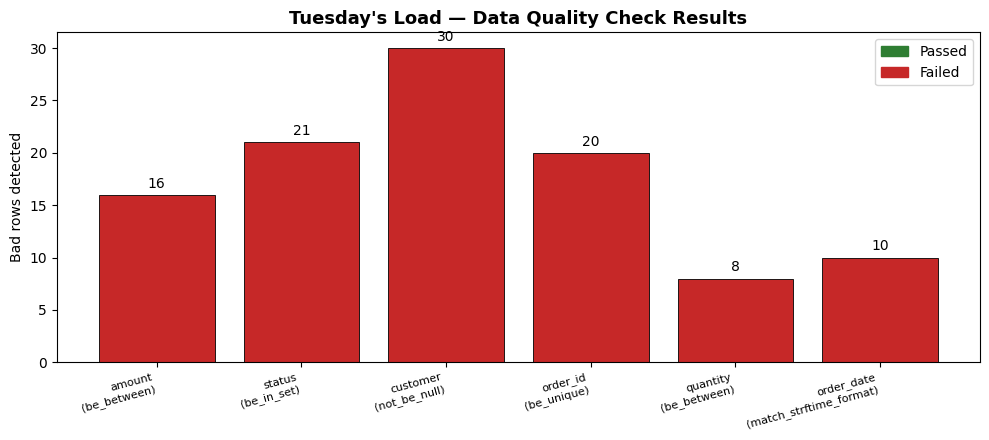

In [85]:
import matplotlib.pyplot as plt

# Pull pass/fail + bad-row counts out of the Tuesday result
labels, bad_counts, colors = [], [], []
for r in result_tuesday.results:
    col = r.expectation_config.kwargs.get("column", "?")
    short = r.expectation_config.type.replace("expect_column_values_to_", "")
    labels.append(f"{col}\n({short})")
    bad_counts.append(r.result.get("unexpected_count", 0))
    colors.append("#2e7d32" if r.success else "#c62828")  # green / red

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, bad_counts, color=colors, edgecolor="black", linewidth=0.6)
ax.set_ylabel("Bad rows detected")
ax.set_title("Tuesday's Load — Data Quality Check Results", fontsize=13, fontweight="bold")
ax.bar_label(bars, padding=3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2e7d32", label="Passed"),
                   Patch(color="#c62828", label="Failed")], loc="upper right")
plt.xticks(rotation=15, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

One glance tells the whole story: four red bars, each labeled with how many rows
violated the rule. *This* is what you put in front of finance instead of making them wait
a week and ask why revenue dropped.

---
## 7. Exercises

Work through these in order. Each has a collapsible solution — try it yourself first,
then click to check. The goal is to move from *hand-rolled thinking* → *GX expectations*
→ *catching a bug you can't see in advance.*

### Exercise 1 — Write a check by hand

The `city` column should only ever contain one of these five cities:
`Istanbul, Ankara, Izmir, Bursa, Antalya`.

Write a function `check_city_allowed(df)` that returns `(passed, violations)` — the same
shape as our earlier hand-rolled checks. Run it on `tuesday`.

*(Hint: Tuesday's city column is actually clean — your check should pass. That's a valid
and important result: a good check confirms when data is fine, too.)*

In [ ]:
# Your code here
ALLOWED_CITIES = {"Istanbul", "Ankara", "Izmir", "Bursa", "Antalya"}

# def check_city_allowed(df):
#     ...


<details>
<summary><b>Show solution</b></summary>

```python
ALLOWED_CITIES = {"Istanbul", "Ankara", "Izmir", "Bursa", "Antalya"}

def check_city_allowed(df):
    violations = df[~df["city"].isin(ALLOWED_CITIES)]
    passed = len(violations) == 0
    return passed, violations

passed, bad = check_city_allowed(tuesday)
print(f"city check → passed: {passed}  ({len(bad)} violations)")
```

This mirrors `check_status_allowed` exactly — same `.isin()` + `~` pattern. Tuesday's
cities are clean, so it passes. A passing check is a feature, not a missed opportunity:
it's positive proof the column is sound.
</details>

### Exercise 2 — Translate it to a Great Expectations expectation

Take the same `city` rule and add it to a **new suite** as a GX expectation, then run it
against `tuesday`. Use the translation table from Section 4 to find the right
expectation.

*(Hint: "values in a known set" → `ExpectColumnValuesToBeInSet`.)*

In [ ]:
# Your code here — build a small suite with just the city expectation and run it


<details>
<summary><b>Show solution</b></summary>

```python
city_suite = context.suites.add(
    gx.ExpectationSuite(name="city_suite")
)
city_suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="city",
        value_set=["Istanbul", "Ankara", "Izmir", "Bursa", "Antalya"],
    )
)

city_vd = context.validation_definitions.add(
    gx.ValidationDefinition(
        name="city_validation", data=batch_definition, suite=city_suite
    )
)
result = city_vd.run(batch_parameters={"dataframe": tuesday})
print("city expectation success:", result.success)
```

Note how the *hand-rolled* version and the *GX* version express the **same rule**. Once
the suite is built, running it against any new batch is a single `.run()` call — that
reusability is the whole point.
</details>

### Exercise 3 — Catch a hidden bug (the mystery batch)

Run the cell below to generate a **mystery batch** with *one* planted problem you haven't
seen. Your job: use the full `orders_quality_suite` (the six-expectation suite from
Section 5) to find out **which expectation fails and how many rows are affected** — without
peeking at the data first.

This is the real-world skill: you don't know what's wrong in advance. The suite tells you.

In [ ]:
# Run this to create the mystery batch — do NOT inspect it manually first!
rng_m = np.random.default_rng(999)
mystery = monday.copy()
# (a planted problem is injected here, hidden from you)
_secret_idx = rng_m.choice(mystery.index, 42, replace=False)
mystery.loc[_secret_idx, "quantity"] = 0
mystery = mystery.sample(frac=1, random_state=3).reset_index(drop=True)
print("Mystery batch ready:", mystery.shape)

In [ ]:
# Your code here — run orders_quality_suite against `mystery`
# and report which expectation fails + how many rows.


<details>
<summary><b>Show solution</b></summary>

```python
result_mystery = validation_definition.run(
    batch_parameters={"dataframe": mystery}
)

print("Overall success:", result_mystery.success)
for r in result_mystery.results:
    if not r.success:
        col = r.expectation_config.kwargs.get("column")
        print(f"FAILED: {r.expectation_config.type} on '{col}' "
              f"→ {r.result['unexpected_count']} bad rows")
```

**The planted bug:** 42 rows had `quantity` set to `0`, which violates
`ExpectColumnValuesToBeBetween(column="quantity", min_value=1)`. You found it without
ever looking at the raw data — *the suite is the bouncer, and it never gets tired.* This
is exactly why we build reusable suites instead of eyeballing every batch.
</details>

---
## 8. Recap & what's next

**What you learned:**

- **Silent bad data is the expensive kind** — it doesn't crash, it lies, and it's found
  too late. Validation is a *contract* enforced at the door (the bouncer).
- **You can validate by hand** with plain Pandas — `<`, `.isin()`, `.isna()`,
  `.duplicated()`. Understanding this makes any framework obvious.
- **Hand-rolled checks stop scaling** — at 50 rules, with no shareable output and no
  standard vocabulary, you need a real tool.
- **Great Expectations (1.x)** gives you battle-tested *expectations*, reusable *suites*,
  and structured *results* — every hand-rolled idea, standardized.
- **Validation is a pipeline gate**, and you decide what happens on failure: fail,
  quarantine, or warn.

**Coming up — Session 8: Working with Data Formats.** We'll look at CSV, JSON, and
Parquet — *how* data is stored, why Parquet is the workhorse of modern data engineering,
and how to profile a dataset's shape and contents. Validation (Session 7) plus formats
(Session 8) together complete your data-quality toolkit before we move into SQL.

---

*Modern Data Engineering · Ameer Ul Islam · DepthWare*